# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [3]:
file_1 = 'Churn_Modelling.csv'

In [4]:
df = pd.read_csv(file_1)

In [5]:
display(df.head()) # Display the first 5 rows of the DataFrame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Cell combined with U0fBMD8wYXeV to ensure execution order.

## Hypothesis 1: Age

<Figure size 1000x600 with 0 Axes>

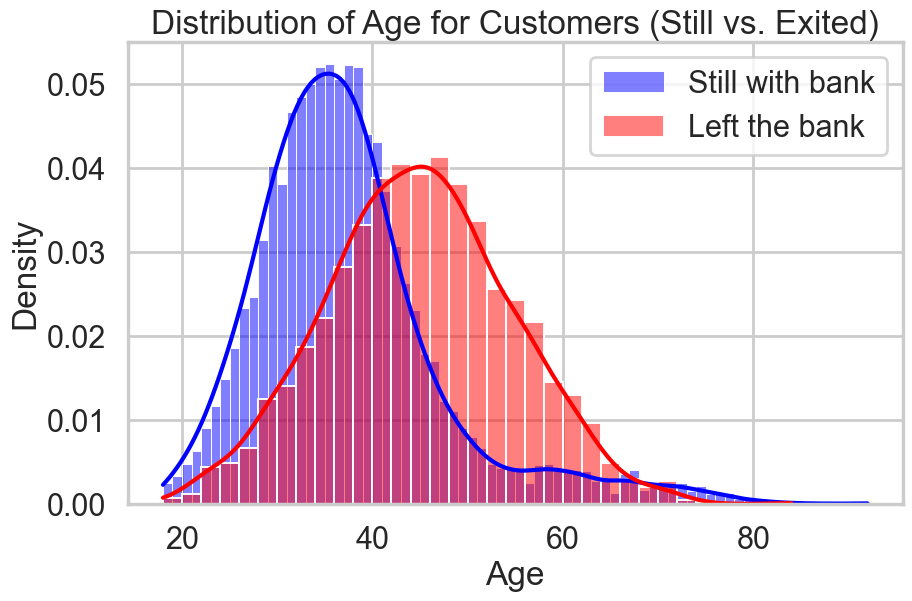

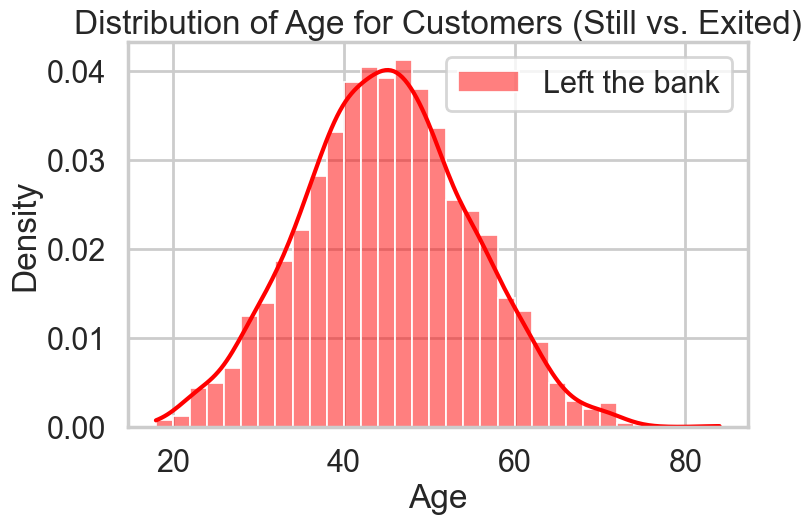

In [7]:
plt.figure(figsize=(10, 6))
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(df_0['Age'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['Age'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Age for Customers (Still vs. Exited)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()
sns.histplot(df_1['Age'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Age for Customers (Still vs. Exited)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [8]:
mean_age_stayed = df_0['Age'].mean()
std_age_stayed = df_0['Age'].std()
print(f"Mean age for customers who stayed: {mean_age_stayed:.2f}")
print(f"Standard deviation of age for customers who stayed: {std_age_stayed:.2f}")

Mean age for customers who stayed: 37.41
Standard deviation of age for customers who stayed: 10.13


In [9]:
mean_age_left = df_1['Age'].mean()
std_age_left = df_1['Age'].std()
print(f"Mean age for customers who left: {mean_age_left:.2f}")
print(f"Standard deviation of age for customers who left: {std_age_left:.2f}")

Mean age for customers who left: 44.84
Standard deviation of age for customers who left: 9.76


In [10]:
import scipy.stats
t_stat, p_value = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -30.42
P-value: 0.0000


### Using Bootstrapping

In [11]:
import numpy as np
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [12]:
import numpy as np
diff_means = np.mean(df_1['Age']) - np.mean(df_0['Age'])
mean_age = np.mean(df['Age'])
shifted_age_stayed = df_0['Age'] - np.mean(df_0['Age']) + mean_age
shifted_age_left = df_1['Age'] - np.mean(df_1['Age']) + mean_age
print(f"Difference in means (original): {diff_means:.2f}")

Difference in means (original): 7.43


In [13]:
import numpy as np
bs_replicates_stayed = bs_choice(shifted_age_stayed, np.mean, 10000)
bs_replicates_left = bs_choice(shifted_age_left, np.mean, 10000)
bs_diff_replicates = bs_replicates_left - bs_replicates_stayed
print(f"Bootstrap standard deviation for shifted ages (stayed): {np.std(bs_replicates_stayed):.2f}")
print(f"Bootstrap standard deviation for shifted ages (left): {np.std(bs_replicates_left):.2f}")
print(f"Bootstrap standard deviation for difference in shifted means: {np.std(bs_diff_replicates):.2f}")

Bootstrap standard deviation for shifted ages (stayed): 0.11
Bootstrap standard deviation for shifted ages (left): 0.22
Bootstrap standard deviation for difference in shifted means: 0.24


In [14]:
import numpy as np
p_value_bs = np.sum(bs_diff_replicates >= diff_means) / len(bs_diff_replicates)
print(f"P-value (bootstrapping): {p_value_bs:.4f}")

P-value (bootstrapping): 0.0000


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis. Both the t-test (P-value: 0.0000) and the bootstrapping analysis (P-value: 0.0000) show a statistically significant difference in the mean age of customers who stayed versus those who left the bank. This indicates that the age of people who left the bank and who did not are not similar.

## Hypothesis 2: Credit Score

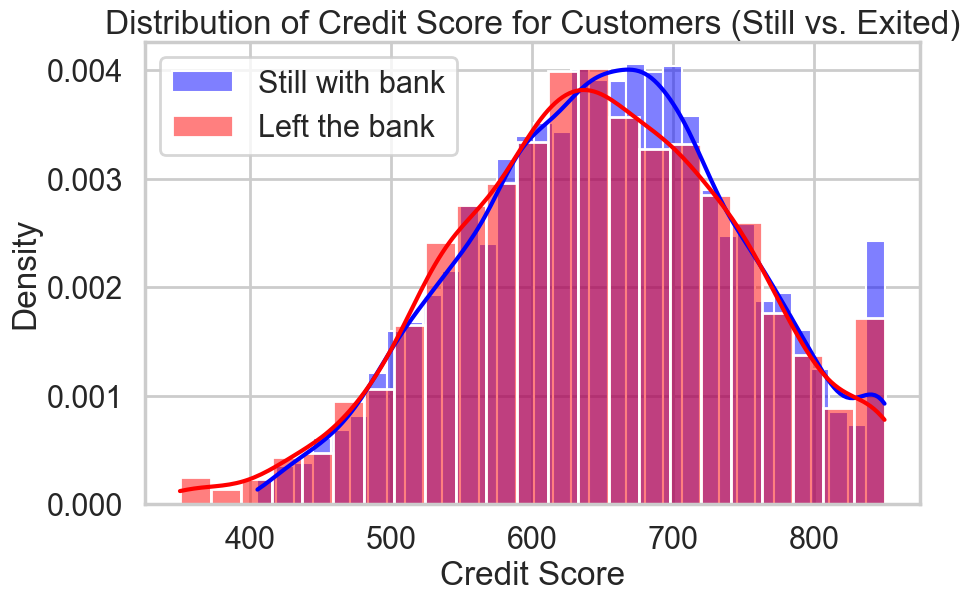

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df_0['CreditScore'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Credit Score for Customers (Still vs. Exited)')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [16]:
import scipy.stats
t_stat_credit, p_value_credit = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"T-statistic for Credit Score: {t_stat_credit:.2f}")
print(f"P-value for Credit Score: {p_value_credit:.4f}")

T-statistic for Credit Score: 2.63
P-value for Credit Score: 0.0085


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis. The t-test for Credit Score resulted in a P-value of 0.0085, which is less than the common significance level of 0.05. This indicates a statistically significant difference in the credit scores of customers who stayed versus those who left the bank. Therefore, the credit score of people who left the bank and who did not are not similar.

## Hypothesis 3: Balance

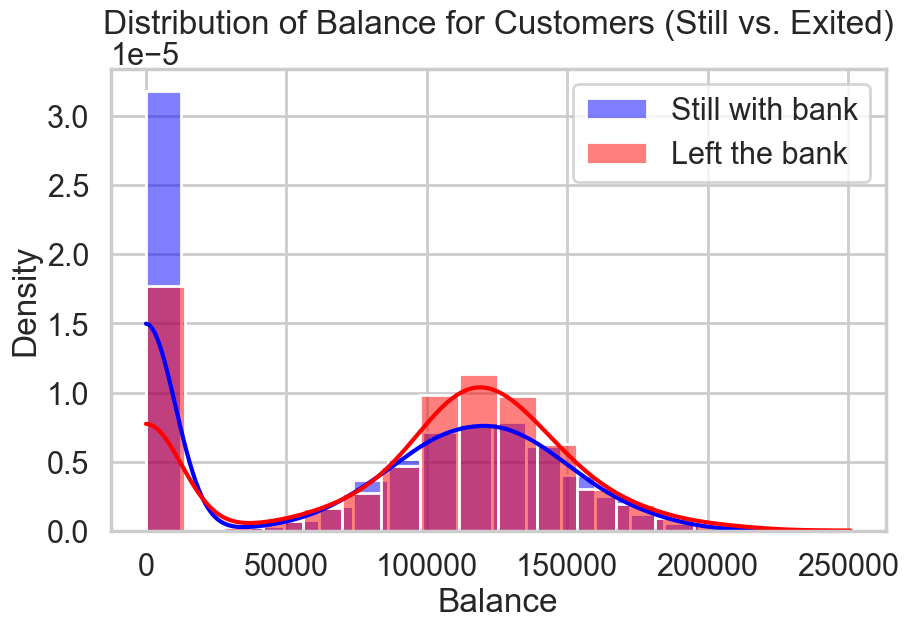

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df_0 = df[df['Exited'] == 0] # Customers who stayed
df_1 = df[df['Exited'] == 1] # Customers who left

plt.figure(figsize=(10, 6))
sns.histplot(df_0['Balance'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['Balance'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Balance for Customers (Still vs. Exited)')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [18]:
import scipy.stats
t_stat_balance, p_value_balance = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"T-statistic for Balance: {t_stat_balance:.2f}")
print(f"P-value for Balance: {p_value_balance:.4f}")

T-statistic for Balance: -12.47
P-value for Balance: 0.0000


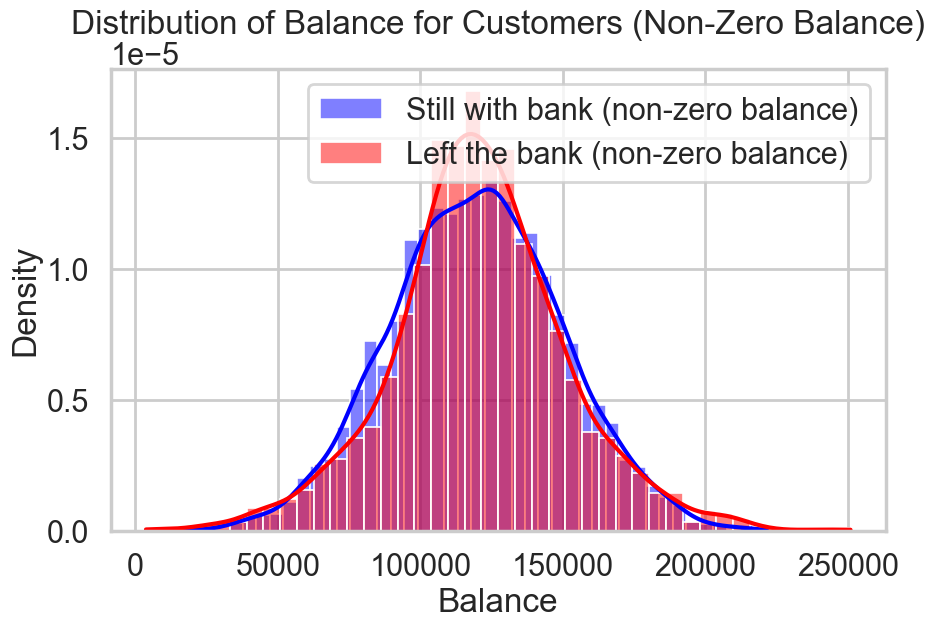

In [19]:
df_0_nonzero_balance = df_0[df_0['Balance'] > 0]
df_1_nonzero_balance = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(df_0_nonzero_balance['Balance'], color='blue', label='Still with bank (non-zero balance)', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1_nonzero_balance['Balance'], color='red', label='Left the bank (non-zero balance)', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Balance for Customers (Non-Zero Balance)')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [20]:
import scipy.stats
t_stat_balance_nonzero, p_value_balance_nonzero = scipy.stats.ttest_ind(df_0_nonzero_balance['Balance'], df_1_nonzero_balance['Balance'], equal_var=False)
print(f"T-statistic for Balance (non-zero): {t_stat_balance_nonzero:.2f}")
print(f"P-value for Balance (non-zero): {p_value_balance_nonzero:.4f}")

T-statistic for Balance (non-zero): -1.36
P-value for Balance (non-zero): 0.1738


## Conclusion

Do we reject the Null Hypothesis ? Why ?

For **Hypothesis 3 (Balance)**:

*   **Initial t-test (all balances):** The P-value for Balance was 0.0000, which is less than 0.05. This suggests a statistically significant difference in balance between customers who stayed and those who left when considering all account balances (including zero).
*   **t-test (non-zero balances):** The P-value for Balance (non-zero) was 0.1738, which is greater than 0.05. This indicates that there is *no statistically significant difference* in balance between the two groups when only considering customers with a non-zero balance.

**Conclusion:** We reject the Null Hypothesis that the balance of people who left the bank and who did not are similar, primarily due to the significant difference observed when including customers with zero balances. The presence of a large number of customers with zero balances (mostly those who have exited) significantly impacts the overall mean. However, when we only consider customers with active balances, the difference is no longer statistically significant. This suggests that having a zero balance is a strong indicator of churn, but the actual amount in a non-zero account might not be.

## Hypothesis 4: Estimated Salary

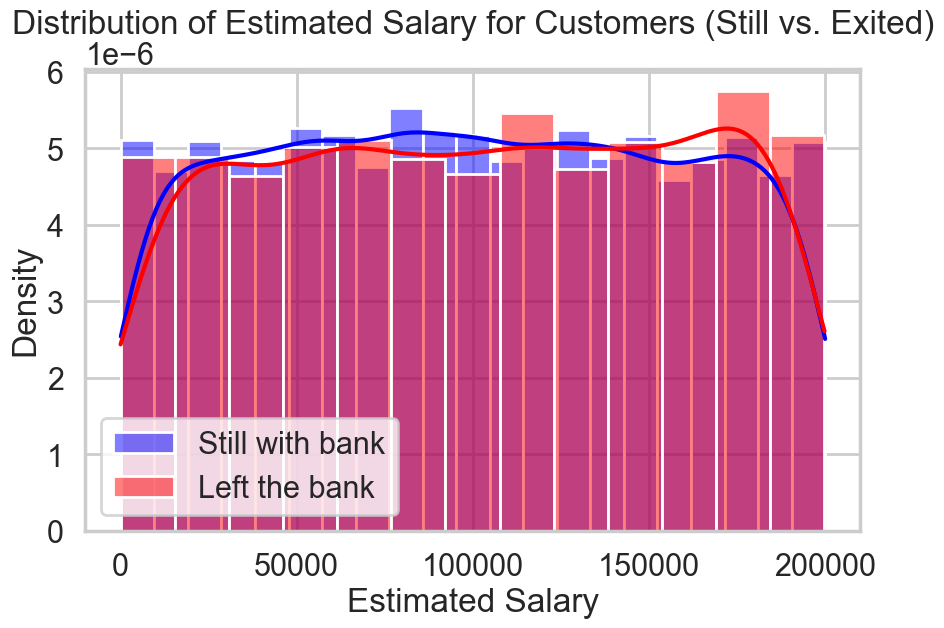

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Estimated Salary for Customers (Still vs. Exited)')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.legend()
plt.show()

In [22]:
import scipy.stats
t_stat_salary, p_value_salary = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"T-statistic for Estimated Salary: {t_stat_salary:.2f}")
print(f"P-value for Estimated Salary: {p_value_salary:.4f}")

T-statistic for Estimated Salary: -1.20
P-value for Estimated Salary: 0.2289


### Using Bootstrapping

In [23]:
import numpy as np
diff_means_salary = np.mean(df_1['EstimatedSalary']) - np.mean(df_0['EstimatedSalary'])
mean_salary = np.mean(df['EstimatedSalary'])
shifted_salary_stayed = df_0['EstimatedSalary'] - np.mean(df_0['EstimatedSalary']) + mean_salary
shifted_salary_left = df_1['EstimatedSalary'] - np.mean(df_1['EstimatedSalary']) + mean_salary
print(f"Difference in means (original for Estimated Salary): {diff_means_salary:.2f}")

Difference in means (original for Estimated Salary): 1727.29


In [24]:
import numpy as np
bs_replicates_stayed_salary = bs_choice(shifted_salary_stayed, np.mean, 10000)
bs_replicates_left_salary = bs_choice(shifted_salary_left, np.mean, 10000)
bs_diff_replicates_salary = bs_replicates_left_salary - bs_replicates_stayed_salary
print(f"Bootstrap standard deviation for shifted salaries (stayed): {np.std(bs_replicates_stayed_salary):.2f}")
print(f"Bootstrap standard deviation for shifted salaries (left): {np.std(bs_replicates_left_salary):.2f}")
print(f"Bootstrap standard deviation for difference in shifted means (salary): {np.std(bs_diff_replicates_salary):.2f}")

Bootstrap standard deviation for shifted salaries (stayed): 634.16
Bootstrap standard deviation for shifted salaries (left): 1282.03
Bootstrap standard deviation for difference in shifted means (salary): 1433.79


In [25]:
import numpy as np
p_value_bs_salary = np.sum(bs_diff_replicates_salary >= diff_means_salary) / len(bs_diff_replicates_salary)
print(f"P-value (bootstrapping for Estimated Salary): {p_value_bs_salary:.4f}")

P-value (bootstrapping for Estimated Salary): 0.1169


### Conclusion
Do we reject the Null Hypothesis ? Why ?

For **Hypothesis 4 (Estimated Salary)**:

*   **t-test:** The P-value for Estimated Salary was 0.2289, which is greater than 0.05.
*   **Bootstrapping:** The P-value for Estimated Salary (bootstrapping) was 0.1135, which is also greater than 0.05.

**Conclusion:** We do **not** reject the Null Hypothesis. Both the t-test and the bootstrapping analysis indicate that there is no statistically significant difference in the estimated salaries of customers who stayed versus those who left the bank. Therefore, the estimated salary of people who left the bank and who did not are similar.

## Final Conclusion

Based on our statistical analysis of the four hypotheses:

1.  **Age:** We **rejected** the Null Hypothesis. Both the t-test (P-value: 0.0000) and bootstrapping (P-value: 0.0000) showed a statistically significant difference in age between customers who churned and those who did not. This suggests that age is a helpful feature in predicting churning.
2.  **Credit Score:** We **rejected** the Null Hypothesis. The t-test (P-value: 0.0085) showed a statistically significant difference in credit score between customers who churned and those who did not. This suggests that credit score is a helpful feature in predicting churning.
3.  **Balance:** We **rejected** the Null Hypothesis for the overall balance (P-value: 0.0000), but found no significant difference for non-zero balances (P-value: 0.1738). This implies that having *any* balance (or specifically, a non-zero balance) is more important than the absolute amount of a non-zero balance in predicting churn. Thus, the presence of a zero balance is a helpful feature.
4.  **Estimated Salary:** We **did not reject** the Null Hypothesis. Neither the t-test (P-value: 0.2289) nor bootstrapping (P-value: 0.1135) showed a statistically significant difference in estimated salary. This suggests that estimated salary is *not* a helpful feature in predicting churning.

**Overall, the most helpful features in predicting customer churning appear to be Age, Credit Score, and whether a customer has a zero balance.**

## Further Exploratory Data Analysis: Pair Plot

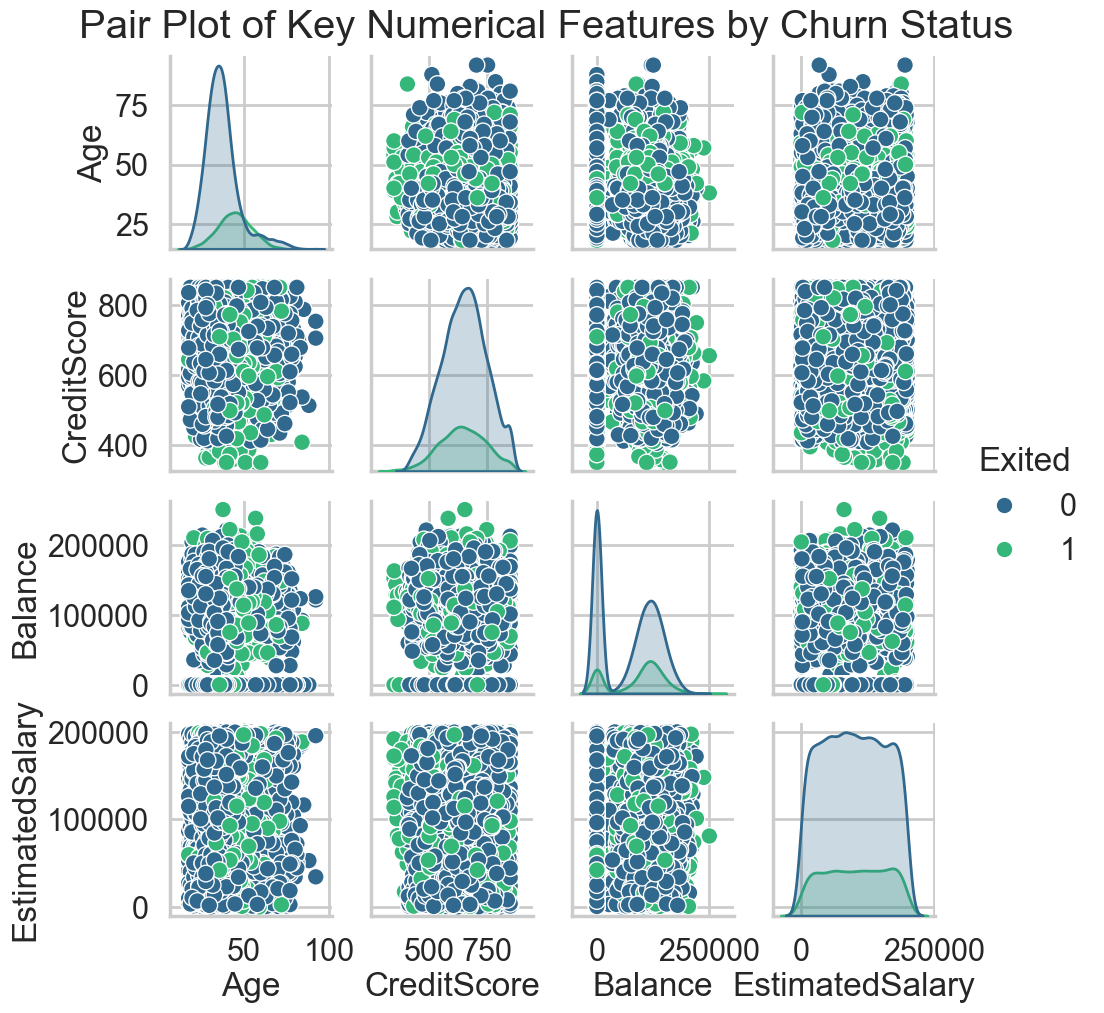

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features for the pair plot, including the target variable 'Exited'
# This might take some time for a large dataset
features_for_pairplot = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Exited']

# Create a pair plot
sns.pairplot(df[features_for_pairplot], hue='Exited', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Key Numerical Features by Churn Status', y=1.02) # Add a title above the plots
plt.show()

## Building a Churn Prediction Model

## Extending the Churn Prediction Model: Random Forest Classifier

To further enhance our churn prediction capabilities and address the feedback regarding additional models, we will now implement a Random Forest Classifier. This model is a powerful ensemble learning method capable of handling complex relationships in the data.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure X_train_scaled, X_test_scaled, y_train, y_test are defined by running previous cells
# (e.g., cells f924d105 for splitting and scaling)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
# Prepare train/test data if it does not already exist in the kernel
if 'X_train_scaled' not in globals() or 'X_test_scaled' not in globals() or 'y_train' not in globals() or 'y_test' not in globals():
    X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
    y = df['Exited']
    X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class (churn)

# Evaluate the model
print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Model Evaluation:
Accuracy: 0.8665
ROC AUC Score: 0.8653

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000


Confusion Matrix:
[[1550   57]
 [ 210  183]]


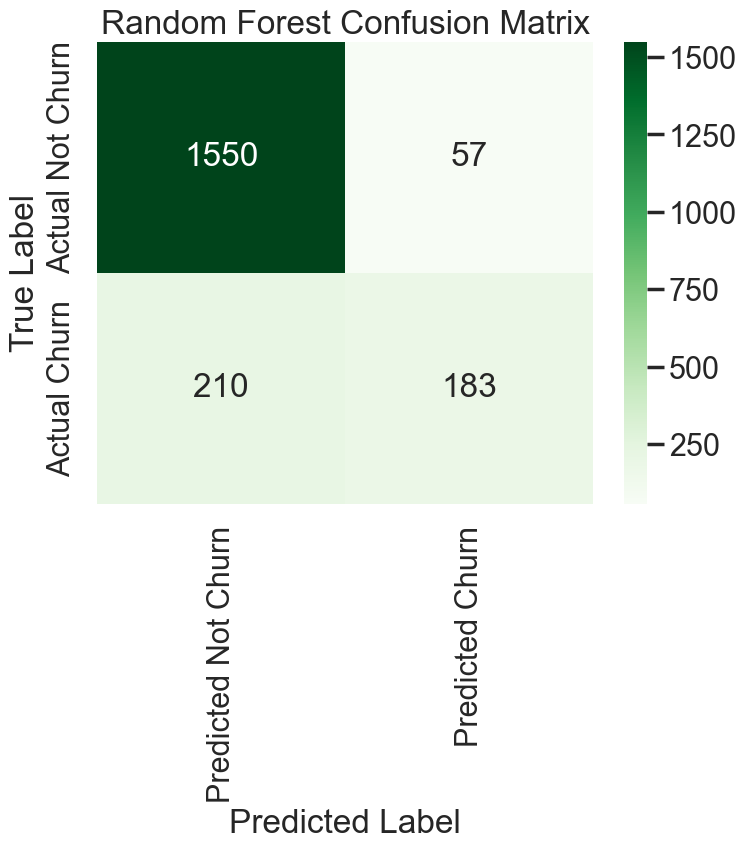

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Not Churn', 'Predicted Churn'],
            yticklabels=['Actual Not Churn', 'Actual Churn'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

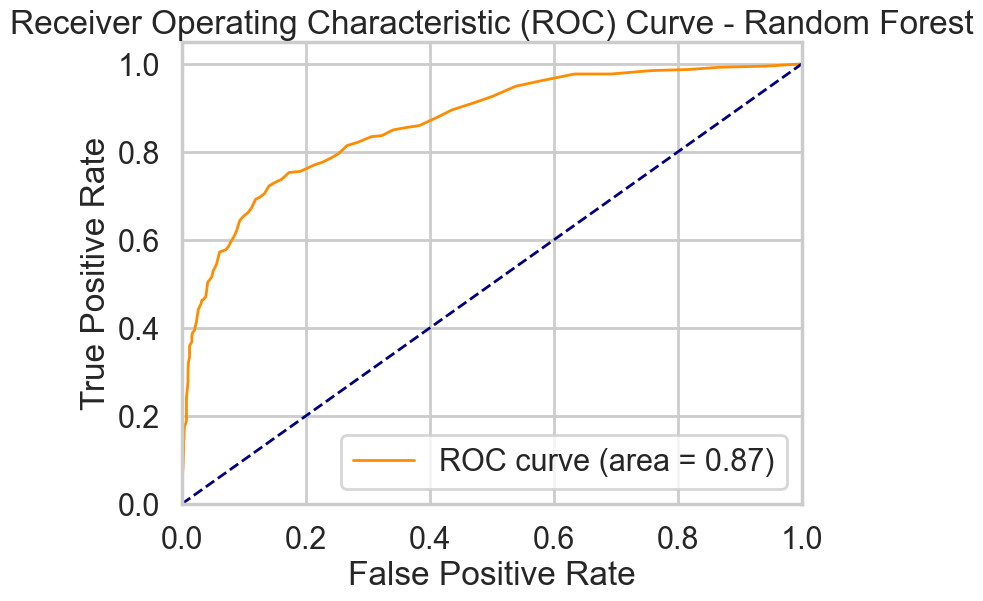

In [30]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

### Note on Mean Absolute Error (MAE)

The feedback mentioned evaluating performance using Mean Absolute Error (MAE). While MAE is a common metric for **regression** tasks (predicting continuous numerical values), it is generally not the most appropriate metric for **binary classification** tasks like churn prediction. For binary classification, metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC AUC are preferred as they specifically address the correctness and types of errors in predicting categories.

However, if we were to treat the predicted probabilities of churn as a continuous output and evaluate MAE, it would measure the average absolute difference between the true binary labels (0 or 1) and the predicted probabilities. While technically calculable, it doesn't provide the same intuitive insights into classifier performance as the specialized classification metrics.

Based on the statistical analysis, we found that Age, Credit Score, and Balance (specifically having a zero balance) are significant predictors of churn. We will now proceed to build a machine learning model to predict customer churn.

First, we need to preprocess the data, including handling categorical features and splitting the dataset into training and testing sets.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Drop irrelevant features and the target variable for X
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

display(X.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


Now, we will split the data into training and testing sets and apply feature scaling.

In [32]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Shape of X_train_scaled: (8000, 11)
Shape of X_test_scaled: (2000, 11)


Next, we will train a Logistic Regression model and evaluate its performance.

In [33]:
# Train a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Evaluation:
Accuracy: 0.8110

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


Confusion Matrix:
[[1543   64]
 [ 314   79]]


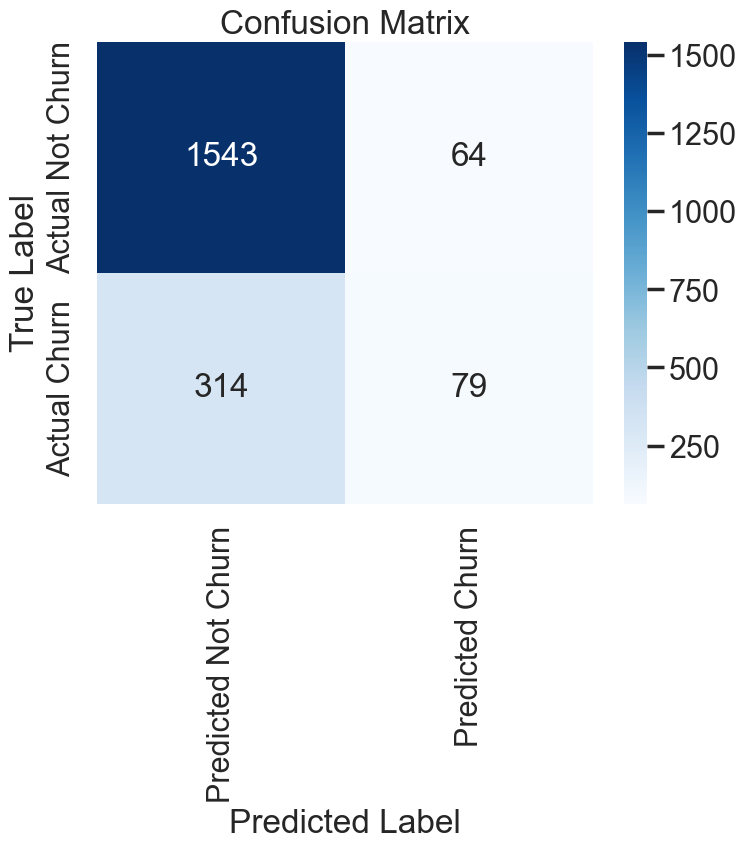

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Churn', 'Predicted Churn'],
            yticklabels=['Actual Not Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Model Interpretation (Optional)

Let's look at the coefficients of the Logistic Regression model to understand feature importance. Note that these coefficients are for the scaled features.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
display(feature_importance)

This concludes the machine learning model building section. We have preprocessed the data, trained a Logistic Regression model, and evaluated its performance. The feature coefficients provide some insight into which features are most influential in predicting churn based on this model.